In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np
import os

In [33]:
DATASET_FILTER = "all_decisions" # "approved" or "all_decisions"

DATASET_DIR = f"./../data/datasets/1995/{DATASET_FILTER}"

EMA = f"{DATASET_DIR}/EMA.csv"
PMDA = f"{DATASET_DIR}/PMDA.csv"
SWISSMEDIC = f"{DATASET_DIR}/Swissmedic.csv"
TGA = f"{DATASET_DIR}/TGA.csv"
FDA = f"{DATASET_DIR}/FDA.csv"
HEALTHCANADA = f"{DATASET_DIR}/HealthCanada.csv"
OVERALL = f"{DATASET_DIR}/Overall.csv"

SAVE_DIR = f"./../analysis/{DATASET_FILTER}/overlap"
os.makedirs(SAVE_DIR, exist_ok=True)

In [34]:
ema = pd.read_csv(EMA)
pmda = pd.read_csv(PMDA)
swissmedic = pd.read_csv(SWISSMEDIC)
tga = pd.read_csv(TGA)
fda = pd.read_csv(FDA)
healthcanada = pd.read_csv(HEALTHCANADA)
overall = pd.read_csv(OVERALL)

In [35]:
overall.head()

,Marketing_authorisation_number,Procedure_number,Drug_name,Non_proprietary_name,Marketing_authorisation_holder,Drug_class,Pharmaceutical_form,Administration_route,Decision,Current_status,...,Nonclinical_abridged,Referral_body,Document_name,Marketing_authorisation_holder_extracted,Agency,Indications_and_usage,Origin,Referral,Disease_name(s),DRUG_CODE
0,ema/939316/2022,emea/h/c/005361/0000,febseltiq,infigratinib,NaN,small molecule,capsule,oral,withdrawn,withdrawn,...,no,na,febseltiq-withdrawal-assessment-report_en.pdf,not reported,EMA,NaN,NaN,NaN,NaN,NaN
1,ema/515905/2024,emea/h/c/006295/0000,wainzua,eplontersen,astrazeneca ab,peptides and proteins,solution,subcutaneous,approved,authorised,...,no,na,wainzua-epar-public-assessment-report_en.pdf,astrazeneca,EMA,NaN,NaN,NaN,NaN,NaN
2,ema/871459/2022,emea/h/c/005483/0000,pluvicto,lutetium (177lu) vipivotide tetraxetan,novartis europharm limited,other,solution,intravenous,approved,authorised,...,no,na,pluvicto-epar-public-assessment-report_en.pdf,novartis,EMA,NaN,NaN,NaN,NaN,NaN
3,ema/549260/2023,emea/h/c/006101/0000,uzpruvo,ustekinumab,stada arzneimittel ag,biologics,solution,subcutaneous,approved,authorised,...,no,na,uzprovo-epar-public-assessment-report_en.pdf,stada,EMA,NaN,NaN,NaN,NaN,NaN
4,ema/309145/2012,emea/h/c/002055,pixuvri,pixantrone,cti life sciences ltd.,small molecule,powder,intravenous,conditional marketing authorisation,withdrawn,...,no,na,pixuvri-epar-public-assessment-report_en.pdf,cti,EMA,NaN,NaN,NaN,NaN,NaN


In [36]:
def plot_agency_distribution(dataset, data_col, figsize=(4.2, 4.2), bar_color='darkseagreen', 
                            edge_color='navy', xlabel_fontsize=12, ylabel_fontsize=12):
    plt.figure(figsize=figsize)
    
    agency_counts = dataset.groupby(data_col)['Agency'].nunique()
    agency_counts.value_counts().sort_index().plot(kind='bar', color=bar_color, edgecolor=edge_color)
    
    plt.xlabel(f'$N$ drug agencies', fontsize=xlabel_fontsize)
    plt.ylabel(f'$N$ {data_col.lower().replace("_", " ")}', fontsize=ylabel_fontsize)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(agency_counts.value_counts().sort_index()):
        plt.text(i, v + max(agency_counts.value_counts()) * 0.001, str(v), 
                 ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_agency_distribution.png", dpi=300)
    plt.show()

def create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens'):
    agencies = dataset['Agency'].unique()
    heatmap = pd.DataFrame(0, index=agencies, columns=agencies)

# Get the total number of drugs per agency
    agency_drug_counts = dataset.groupby('Agency')[data_col].nunique()
    for drug in dataset[data_col].unique():
        involved_agencies = dataset[dataset[data_col] == drug]['Agency'].unique()
        for agency1, agency2 in combinations(involved_agencies, 2):
            heatmap.loc[agency1, agency2] += 1
            heatmap.loc[agency2, agency1] += 1

# Normalize by column (x-axis) agency's total drug count
    heatmap_normalized = heatmap.copy()
    for j, agency_col in enumerate(agencies):  # j is column (x-axis)
        for i, agency_row in enumerate(agencies):  # i is row (y-axis)
            if i != j:
            # Divide by the column agency's total drugs
                heatmap_normalized.loc[agency_row, agency_col] = (
                heatmap.loc[agency_row, agency_col] / agency_drug_counts[agency_col]
            )

    plt.figure(figsize=figsize)
    plt.imshow(heatmap_normalized, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Proportion of Column Agency Drugs')
    plt.xticks(ticks=np.arange(len(agencies)), labels=agencies, rotation=45)
    plt.yticks(ticks=np.arange(len(agencies)), labels=agencies)

# Add text with absolute and percentage values
    for i in range(len(agencies)):
        for j in range(len(agencies)):
            if i != j:  # Skip diagonal
                abs_value = int(heatmap.iloc[i, j])
                prop_value = heatmap_normalized.iloc[i, j]
            # text_color = 'white' if prop_value > 0.5 else 'black'
                text_color = "black"
                # round percent to integer if >=10%, else 1 decimal place
                if prop_value >= 0.1:
                    prop_text = f'{prop_value:.0%}'
                else:
                    prop_text = f'{prop_value:.1%}'
                plt.text(j, i, f'{abs_value}\n({prop_text})', 
                    ha='center', va='center', 
                    color=text_color, fontsize=9)

    # plt.title('Shared Drugs (% of horizontal axis agency)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{data_col}_normalized_heatmap.png", dpi=300)
    plt.show()

def analyze_drug_duplicates(dataset, data_col, top_n_drugs=2):

    # Create a subset df with drug names which appear multiple times within the SAME agency
    duplicates_within_agency = dataset[dataset.duplicated(subset=[data_col, 'Agency'], keep=False)]
    
    # Find drug names which are cross-agency duplicates (appear in multiple different agencies)
    cross_agency_duplicates = dataset[dataset.duplicated(subset=[data_col], keep=False)]
    
    # Drop in-agency duplicates from this subset to keep only cross-agency duplicates
    cross_agency_duplicates = cross_agency_duplicates[~cross_agency_duplicates.index.isin(duplicates_within_agency.index)]
    
    # Find the top shared drugs across multiple agencies and create df subset with them
    drug_agency_count = dataset.groupby(data_col)['Agency'].nunique()
    top_shared_drugs = drug_agency_count[drug_agency_count > top_n_drugs].index.tolist()
    top_shared_drugs_df = dataset[dataset[data_col].isin(top_shared_drugs)]
    
    print(20 * "-")
    print(f"{len(dataset):<10} Length of the combined (overall) dataset including all datapoints")
    print(f"{len(duplicates_within_agency):<10} Length of the subset including in-agency duplicates ({data_col} present multiple times within the same agency)")
    print(f"{len(cross_agency_duplicates):<10} Length of the subset including cross-agency duplicates ({data_col} present in multiple different agencies)")
    print(20 * "-")
    print(f"{dataset[data_col].nunique():<10} N of unique {data_col} in the combined dataset")
    print(f"{duplicates_within_agency[data_col].nunique():<10} N of unique {data_col} in the in-agency duplicates subset")
    print(f"{cross_agency_duplicates[data_col].nunique():<10} N of unique {data_col} in the cross-agency duplicates subset")
    
    return {
        'duplicates_within_agency': duplicates_within_agency,
        'cross_agency_duplicates': cross_agency_duplicates,
        'top_shared_drugs_df': top_shared_drugs_df,
        'top_shared_drugs': top_shared_drugs
    }

In [37]:
def analyze_agency_drug_sharing(dataset, data_col='Drug_name', output_file=None):

    agencies = sorted(dataset['Agency'].unique())
    
    # Filter out rows with missing drug names
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Create a mapping of drug to set of agencies
    drug_to_agencies = dataset_clean.groupby(data_col)['Agency'].apply(set).to_dict()
    
    # Initialize results dictionary
    results = {agency: {} for agency in agencies}
    
    # Prepare output capture
    output_lines = []
    
    # For each agency, analyze its drugs
    for agency in agencies:
        # Get unique drugs for this agency, excluding NaN values
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        # Count how many agencies each drug appears in (beyond the current agency)
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            # Count other agencies (excluding current agency)
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        # Calculate percentages
        for n_shared in sharing_counts:
            percentage = (sharing_counts[n_shared] / total_drugs) * 100
            results[agency][n_shared] = percentage
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results).T
    results_df = results_df.fillna(0).sort_index(axis=1)
    
    # Rename columns for clarity
    column_names = {}
    for col in results_df.columns:
        if col == 0:
            column_names[col] = 'Unique to agency'
        elif col == 1:
            column_names[col] = 'Shared with 1 other'
        else:
            column_names[col] = f'Shared with {col} others'
    results_df = results_df.rename(columns=column_names)
    
    # Display results
    def print_and_capture(text):
        print(text)
        output_lines.append(text)
    
    print_and_capture(f"\n{'='*80}")
    print_and_capture(f"Drug Sharing Analysis by Agency (unique deduped entries based on {data_col})")
    print_and_capture(f"{'='*80}\n")
    
    print_and_capture(f"Percentages represent proportion of each agency's unique deduped entries by {data_col}:\n")
    print_and_capture(results_df.round(2).to_string())
    
    # Also print absolute counts
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Absolute counts (by unique deduped entry in {data_col}):")
    print_and_capture(f"{'='*80}\n")
    
    # Calculate absolute counts
    counts_results = {agency: {} for agency in agencies}
    for agency in agencies:
        agency_drugs = dataset_clean[dataset_clean['Agency'] == agency][data_col].unique()
        total_drugs = len(agency_drugs)
        
        if total_drugs == 0:
            continue
        
        sharing_counts = {}
        for drug in agency_drugs:
            agencies_with_drug = drug_to_agencies.get(drug, set())
            n_other_agencies = len(agencies_with_drug) - 1
            sharing_counts[n_other_agencies] = sharing_counts.get(n_other_agencies, 0) + 1
        
        for n_shared in sharing_counts:
            counts_results[agency][n_shared] = sharing_counts[n_shared]
    
    counts_df = pd.DataFrame(counts_results).T
    counts_df = counts_df.fillna(0).sort_index(axis=1).astype(int)
    counts_df = counts_df.rename(columns=column_names)
    
    print_and_capture(counts_df.to_string())
    
    # Summary statistics
    print_and_capture(f"\n\n{'='*80}")
    print_and_capture(f"Summary Statistics by unique deduped {data_col}:")
    print_and_capture(f"{'='*80}\n")
    
    for agency in agencies:
        total = len(dataset_clean[dataset_clean['Agency'] == agency][data_col])
        total_deduped = dataset_clean[dataset_clean['Agency'] == agency][data_col].nunique()
        unique = counts_df.loc[agency, 'Unique to agency'] if 'Unique to agency' in counts_df.columns else 0
        print_and_capture(f"{agency:15} - Total: {total:4}, Total deduped: {total_deduped:4}, Unique to this agency: {unique:4} ({unique/total_deduped*100:.1f}%)")
    
    # Save to file if output_file is specified
    if output_file:
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write('\n'.join(output_lines))
        print(f"\n Analysis saved to: {output_file}")
    
    return results_df, counts_df

In [ ]:
def get_top_duplicated_drugs(dataset, data_col='Drug_name', top_n=15):
    """
    Find the top N drugs with the most duplicate entries in the dataset.
    
    Parameters:
    -----------
    dataset : pd.DataFrame
        The dataset to analyze
    data_col : str
        The column name to group by (e.g., 'Drug_name' or 'Non_proprietary_name')
    top_n : int
        Number of top drugs to return (default: 15)
    
    Returns:
    --------
    pd.DataFrame : Subset of the dataset containing only rows for the top N most duplicated drugs,
                   sorted by data_col and then by Agency
    """
    # Filter out rows with missing values in data_col
    dataset_clean = dataset[dataset[data_col].notna()].copy()
    
    # Count occurrences of each drug
    drug_counts = dataset_clean[data_col].value_counts()
    
    # Get top N drugs with most duplicates
    top_drugs = drug_counts.head(top_n).index.tolist()
    
    # Filter dataset for these top drugs
    top_drugs_df = dataset_clean[dataset_clean[data_col].isin(top_drugs)].copy()
    
    # Sort by data_col and then by Agency for easy comparison
    top_drugs_df = top_drugs_df.sort_values([data_col, 'Agency'])
    
    print(f"\nTop {top_n} drugs with most entries (by {data_col}):")
    print(f"{'='*80}\n")
    for i, (drug, count) in enumerate(drug_counts.head(top_n).items(), 1):
        agencies = dataset_clean[dataset_clean[data_col] == drug]['Agency'].unique()
        print(f"{i:2}. {drug:40} - {count:3} entries across {len(agencies)} agencies: {', '.join(sorted(agencies))}")
        
    
    return top_drugs_df

In [38]:
overall.head(2)

,Marketing_authorisation_number,Procedure_number,Drug_name,Non_proprietary_name,Marketing_authorisation_holder,Drug_class,Pharmaceutical_form,Administration_route,Decision,Current_status,...,Nonclinical_abridged,Referral_body,Document_name,Marketing_authorisation_holder_extracted,Agency,Indications_and_usage,Origin,Referral,Disease_name(s),DRUG_CODE
0,ema/939316/2022,emea/h/c/005361/0000,febseltiq,infigratinib,NaN,small molecule,capsule,oral,withdrawn,withdrawn,...,no,na,febseltiq-withdrawal-assessment-report_en.pdf,not reported,EMA,NaN,NaN,NaN,NaN,NaN
1,ema/515905/2024,emea/h/c/006295/0000,wainzua,eplontersen,astrazeneca ab,peptides and proteins,solution,subcutaneous,approved,authorised,...,no,na,wainzua-epar-public-assessment-report_en.pdf,astrazeneca,EMA,NaN,NaN,NaN,NaN,NaN


# Analyse duplicates by drug_name

In [47]:
results = analyze_drug_duplicates(dataset=overall, data_col='Drug_name', top_n_drugs=10)

--------------------
32215      Length of the combined (overall) dataset including all datapoints
22668      Length of the subset including in-agency duplicates (Drug_name present multiple times within the same agency)
2886       Length of the subset including cross-agency duplicates (Drug_name present in multiple different agencies)
--------------------
10934      N of unique Drug_name in the combined dataset
3573       N of unique Drug_name in the in-agency duplicates subset
1247       N of unique Drug_name in the cross-agency duplicates subset


In [48]:
print(results)

{'duplicates_within_agency':       Marketing_authorisation_number      Procedure_number      Drug_name  \
106                  ema/724003/2018  emea/h/c/004915/0000       fulphila   
278                  ema/523054/2017         emea/h/c/4262       fulphila   
425                  ema/000309/2007       emea/h/c/000309          sb309   
879                  ema/425550/2018  emea/h/c/004789/0000       efgratin   
1162             ema/chmp/86716/2018  emea/h/c/004052/0000        mektovi   
...                              ...                   ...            ...   
32208                       02555964                   NaN       lazcluze   
32209                       02555972                   NaN       lazcluze   
32210                       02556146                   NaN         zoryve   
32213                       02557282                   NaN  jamp edoxaban   
32214                       02557290                   NaN  jamp edoxaban   

                           Non_proprietary_nam

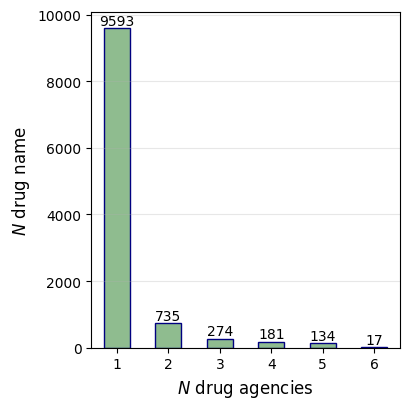

In [40]:
plot_agency_distribution(overall, 'Drug_name')

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_35932\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.09928656361474435' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_35932\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5335463258785943' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_35932\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.841025641025641' has dtype incompatible with int64, please explicitly cast to

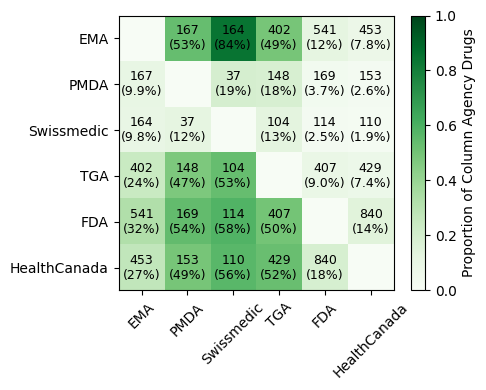

In [41]:
create_normalized_heatmap(dataset=overall, data_col='Drug_name', figsize=(5, 4), cmap='Greens')

In [42]:
analyze_agency_drug_sharing(dataset=overall, data_col='Drug_name', output_file=f"{SAVE_DIR}/drug_name_analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Drug_name)

Percentages represent proportion of each agency's unique deduped entries by Drug_name:

              Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others  Shared with 4 others  Shared with 5 others
EMA                      54.82                16.17                 10.52                  9.51                  7.97                  1.01
FDA                      76.28                12.20                  4.76                  3.52                  2.86                  0.37
HealthCanada             83.18                 7.82                  3.62                  2.85                  2.25                  0.29
PMDA                     32.27                 8.63                  8.95                 17.25                 27.48                  5.43
Swissmedic               10.26                15.90                 14.87                 18.97                 31.28                 

(              Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                  54.815696            16.171225             10.523187   
 FDA                  76.282757            12.199956              4.756662   
 HealthCanada         83.179012             7.818930              3.617970   
 PMDA                 32.268371             8.626198              8.945687   
 Swissmedic           10.256410            15.897436             14.871795   
 TGA                  28.728606            15.892421             19.682152   
 
               Shared with 3 others  Shared with 4 others  Shared with 5 others  
 EMA                       9.512485              7.966706              1.010702  
 FDA                       3.523453              2.862806              0.374367  
 HealthCanada              2.846365              2.246228              0.291495  
 PMDA                     17.252396             27.476038              5.431310  
 Swissmedic               18.974359       

In [50]:
# Get top 15 drugs with most duplicates
top_duplicated_df = get_top_duplicated_drugs(dataset=overall, data_col='Drug_name', top_n=15)
top_duplicated_df


Top 15 drugs with most entries (by Drug_name):

 1. metformin hydrochloride                  - 104 entries across 1 agencies: FDA
 2. levetiracetam                            - 100 entries across 2 agencies: FDA, HealthCanada
 3. hydrocodone bitartrate and acetaminophen -  98 entries across 1 agencies: FDA
 4. famotidine                               -  79 entries across 2 agencies: FDA, HealthCanada
 5. gabapentin                               -  78 entries across 2 agencies: FDA, HealthCanada
 6. ranitidine hydrochloride                 -  75 entries across 1 agencies: FDA
 7. pregabalin                               -  75 entries across 2 agencies: FDA, HealthCanada
 8. clobetasol propionate                    -  74 entries across 1 agencies: FDA
 9. potassium chloride                       -  74 entries across 1 agencies: FDA
10. ibuprofen                                -  72 entries across 2 agencies: FDA, HealthCanada
11. acyclovir                                -  71 entries ac

,Marketing_authorisation_number,Procedure_number,Drug_name,Non_proprietary_name,Marketing_authorisation_holder,Drug_class,Pharmaceutical_form,Administration_route,Decision,Current_status,...,Nonclinical_abridged,Referral_body,Document_name,Marketing_authorisation_holder_extracted,Agency,Indications_and_usage,Origin,Referral,Disease_name(s),DRUG_CODE
4825,anda074556,NaN,acyclovir,acyclovir,teva,small molecule,tablet,oral,approved,authorised,...,yes,NaN,NaN,teva,FDA,NaN,fda,no,NaN,NaN
4837,anda074570,NaN,acyclovir,acyclovir,roxane,small molecule,capsule,oral,conditional marketing authorisation,discontinued,...,yes,NaN,NaN,roxane,FDA,NaN,fda,no,NaN,NaN
4841,anda074578,NaN,acyclovir,acyclovir,teva,small molecule,capsule,oral,approved,authorised,...,yes,NaN,NaN,teva,FDA,NaN,fda,no,NaN,NaN
4899,anda074658,NaN,acyclovir,acyclovir,lek pharm,small molecule,tablet,oral,conditional marketing authorisation,discontinued,...,yes,NaN,NaN,lek,FDA,NaN,fda,no,NaN,NaN
4909,anda074674,NaN,acyclovir,acyclovir,ivax sub teva pharms,small molecule,capsule,oral,approved,discontinued,...,yes,NaN,NaN,teva,FDA,NaN,fda,no,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14451,anda210250,NaN,ranitidine hydrochloride,ranitidine hydrochloride,thinq pharm-cro pvt,NaN,tablet,oral,approved,discontinued,...,yes,NaN,NaN,thinq,FDA,NaN,fda,no,NaN,NaN
14685,anda210681,NaN,ranitidine hydrochloride,ranitidine hydrochloride,novitium pharma,NaN,capsule,oral,approved,discontinued,...,yes,NaN,NaN,novitium,FDA,NaN,fda,no,NaN,NaN
14891,anda211058,NaN,ranitidine hydrochloride,ranitidine hydrochloride,aurobindo pharma,NaN,capsule,oral,approved,discontinued,...,yes,NaN,NaN,aurobindo,FDA,NaN,fda,no,NaN,NaN
15026,anda211289,NaN,ranitidine hydrochloride,ranitidine hydrochloride,vkt pharma,NaN,tablet,oral,approved,authorised,...,yes,NaN,NaN,vkt,FDA,NaN,fda,no,NaN,NaN


# Analyze duplicates by Non_proprietary_name

In [43]:
results = analyze_drug_duplicates(dataset=overall, data_col='Non_proprietary_name', top_n_drugs=10)

--------------------
32215      Length of the combined (overall) dataset including all datapoints
28292      Length of the subset including in-agency duplicates (Non_proprietary_name present multiple times within the same agency)
1694       Length of the subset including cross-agency duplicates (Non_proprietary_name present in multiple different agencies)
--------------------
4654       N of unique Non_proprietary_name in the combined dataset
2121       N of unique Non_proprietary_name in the in-agency duplicates subset
835        N of unique Non_proprietary_name in the cross-agency duplicates subset


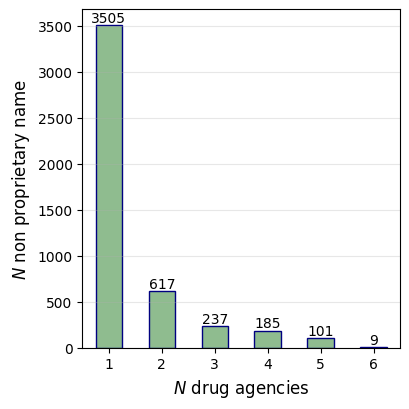

In [44]:
plot_agency_distribution(overall, 'Non_proprietary_name')

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_35932\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.15159817351598173' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_35932\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.538961038961039' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  heatmap_normalized.loc[agency_row, agency_col] = (
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_35932\3832251816.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6341463414634146' has dtype incompatible with int64, please explicitly cast to

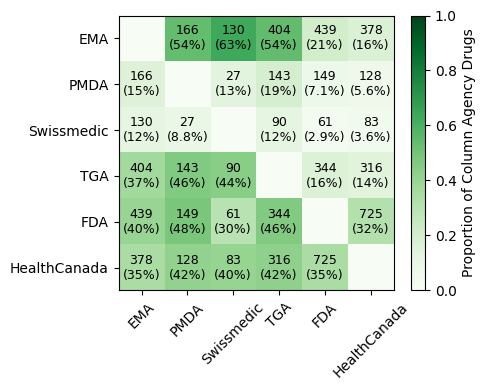

In [45]:
create_normalized_heatmap(dataset=overall, data_col='Non_proprietary_name', figsize=(5, 4), cmap='Greens')

In [46]:
analyze_agency_drug_sharing(dataset=overall, data_col='Non_proprietary_name', output_file=f"{SAVE_DIR}/non_proprietary_name_analysis.txt")


Drug Sharing Analysis by Agency (unique deduped entries based on Non_proprietary_name)

Percentages represent proportion of each agency's unique deduped entries by Non_proprietary_name:

              Unique to agency  Shared with 1 other  Shared with 2 others  Shared with 3 others  Shared with 4 others  Shared with 5 others
EMA                      40.64                16.89                 16.62                 15.80                  9.22                  0.82
FDA                      56.05                23.45                  8.44                  7.10                  4.53                  0.43
HealthCanada             64.78                16.56                  6.58                  7.37                  4.32                  0.39
PMDA                     32.14                11.69                 12.34                 15.58                 25.32                  2.92
Swissmedic               31.22                12.20                 16.10                 20.00                 

(              Unique to agency  Shared with 1 other  Shared with 2 others  \
 EMA                  40.639269            16.894977             16.621005   
 FDA                  56.053384            23.450906              8.436606   
 HealthCanada         64.777681            16.564952              6.582389   
 PMDA                 32.142857            11.688312             12.337662   
 Swissmedic           31.219512            12.195122             16.097561   
 TGA                  31.375167            15.487316             17.356475   
 
               Shared with 3 others  Shared with 4 others  Shared with 5 others  
 EMA                      15.799087              9.223744              0.821918  
 FDA                       7.102002              4.528122              0.428980  
 HealthCanada              7.367044              4.315606              0.392328  
 PMDA                     15.584416             25.324675              2.922078  
 Swissmedic               20.000000       

In [ ]:
# Get top 15 drugs with most duplicates by Non_proprietary_name
top_duplicated_nonprop_df = get_top_duplicated_drugs(dataset=overall, data_col='Non_proprietary_name', top_n=15)
top_duplicated_nonprop_df